# TimeGAN augmented data with 8 covariate

In [1]:
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import importlib
import gc
import tensorflow as tf
from tensorflow.keras import backend as K

#!git clone https://github.com/Meowth239/dse4101-project.git
#!git -C /content/dse4101-project checkout LSTM_r
#import sys
#sys.path.append('/content/dse4101-project/lstm_src')

import my_lstm
import importlib
importlib.reload(my_lstm)

from my_lstm import build_lstm_model, create_sequences, expanding_window_lstm_forecast

In [9]:
df = pd.read_csv('../data/timegan_outputs/timegan_stitched_with_real.csv')
#df = pd.read_csv('/content/dse4101-project/data/timegan_outputs/timegan_stitched_with_real.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1958-02-01,0.024847,-0.015705,0.027807,-0.027773,-0.000809,0.185145,0.006441,0.000379,0.019757
1,1958-03-01,0.027390,-0.022099,0.024366,-0.029438,0.003339,0.215476,0.009997,0.003410,0.114539
2,1958-04-01,0.004842,-0.011170,0.019614,-0.000271,0.002325,0.159208,-0.003944,-0.001126,0.101262
3,1958-05-01,-0.016618,-0.006536,-0.012564,0.000679,-0.000740,0.254986,-0.008159,-0.004714,0.055544
4,1958-06-01,-0.002823,-0.000563,-0.024216,0.003817,0.002150,0.169251,0.000508,-0.001069,0.086817


In [10]:
feature_cols = [
    "AUD_USD_ret",
    "CAD_USD_ret",
    "NZD_USD_ret",
    "ZAR_USD_ret",
    "CPI",
    "TB3MS",
    "M1",
    "M2",
    "wti_ret"
]

target_col = "wti_ret"

In [11]:
df = df.sort_values("Date").reset_index(drop=True)

# compute indices based on original evaluation and test split
train_size = df.index[df["Date"] < "2014-02-01"][-1] + 1
val_end = df.index[df["Date"] <= "2020-01-01"][-1] + 1

# split using iloc
train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:val_end]
test_data = df.iloc[val_end:]

print(f"Train data length: {len(train_data)}")
print(f"Validation data length: {len(val_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 672
Validation data length: 72
Test data length: 72


In [5]:
# grid search over hyperparameters for the expanding window LSTM
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
}
param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

results_grid = []
failed_combos = []

max_retries = 2

for i, (lb, dr, units, ep) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    success = False

    for attempt in range(1, max_retries + 1):
        try:
            print(f"Attempt {attempt}/{max_retries}")

            # cleanup before each attempt
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

            val_forecasts = expanding_window_lstm_forecast(
                df=df,
                feature_cols=feature_cols,
                target_col=target_col,
                initial_train_size=train_size,
                end_idx=val_end,
                date_col="Date",
                lookback=lb,
                units=units,
                dropout=dr,
                epochs=ep,
                batch_size=32,
                verbose=0,
                scale=True,
                seed=42
            )

            if len(val_forecasts) == 0:
                raise ValueError("No forecasts generated")

            mse = mean_squared_error(
                val_forecasts["actual"],
                val_forecasts["predicted"]
            )

            print(f"Validation MSE: {mse:.6f}")

            results_grid.append({
                "lookback": lb,
                "dropout": dr,
                "units": units,
                "epochs": ep,
                "mse": mse,
                "attempt_used": attempt
            })

            success = True
            break

        except Exception as e:
            print(f"Error on attempt {attempt}: {e}")

            # cleanup after failure
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

    if not success:
        print("Failed after all retries.")
        failed_combos.append({
            "lookback": lb,
            "dropout": dr,
            "units": units,
            "epochs": ep
        })

# --------------------------------------------------
# results
# --------------------------------------------------

results_grid_df = pd.DataFrame(results_grid).sort_values("mse").reset_index(drop=True)
failed_combos_df = pd.DataFrame(failed_combos)


[1/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=50
Attempt 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Validation MSE: 0.364048

[2/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=100
Attempt 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Validation MSE: 0.670781

[3/16] Testing params:
lookback=2, dropout=0.001, units=170, epochs=50
Attempt 1/2


...

Validation MSE: 0.629406

[15/16] Testing params:
lookback=10, dropout=0.1, units=170, epochs=50
Attempt 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Validation MSE: 0.601944

[16/16] Testing params:
lookback=10, dropout=0.1, units=170, epochs=100
Attempt 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Validation MSE: 0.593482


In [6]:
results_grid

[{'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.36404840208018563,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.6707808745383333,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 50,
  'mse': 0.44063610396137853,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 0.7232272813847131,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.2828238891259166,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.3801953365750015,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.35038678698022846,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.48895535990563843,
  'attempt_used': 1},
 {'lookback': 10,
  'dropout': 0.001,
  'uni

In [3]:
results_grid = [
    {'lookback': 2, 'dropout': 0.001, 'units': 50, 'epochs': 50, 'mse': 0.36404840208018563, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.001, 'units': 50, 'epochs': 100, 'mse': 0.6707808745383333, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.001, 'units': 170, 'epochs': 50, 'mse': 0.44063610396137853, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.001, 'units': 170, 'epochs': 100, 'mse': 0.7232272813847131, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.1, 'units': 50, 'epochs': 50, 'mse': 0.2828238891259166, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.1, 'units': 50, 'epochs': 100, 'mse': 0.3801953365750015, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.1, 'units': 170, 'epochs': 50, 'mse': 0.35038678698022846, 'attempt_used': 1},
    {'lookback': 2, 'dropout': 0.1, 'units': 170, 'epochs': 100, 'mse': 0.48895535990563843, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.001, 'units': 50, 'epochs': 50, 'mse': 0.597848652064256, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.001, 'units': 50, 'epochs': 100, 'mse': 0.6297918683575009, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.001, 'units': 170, 'epochs': 50, 'mse': 0.6380836141364502, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.001, 'units': 170, 'epochs': 100, 'mse': 0.6066929019399142, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.1, 'units': 50, 'epochs': 50, 'mse': 0.5049728829793003, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.1, 'units': 50, 'epochs': 100, 'mse': 0.6294060628364004, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.1, 'units': 170, 'epochs': 50, 'mse': 0.6019435444535011, 'attempt_used': 1},
    {'lookback': 10, 'dropout': 0.1, 'units': 170, 'epochs': 100, 'mse': 0.5934817272284735, 'attempt_used': 1}
]

In [5]:
results_df = pd.DataFrame(results_grid)
results_df = results_df.sort_values("mse")

print(results_df.head())

best_params = results_df.iloc[0]
print(best_params)

   lookback  dropout  units  epochs       mse  attempt_used
4         2    0.100     50      50  0.282824             1
6         2    0.100    170      50  0.350387             1
0         2    0.001     50      50  0.364048             1
5         2    0.100     50     100  0.380195             1
2         2    0.001    170      50  0.440636             1
lookback         2.000000
dropout          0.100000
units           50.000000
epochs          50.000000
mse              0.282824
attempt_used     1.000000
Name: 4, dtype: float64


# Out of sample testing

In [13]:
# best parameters from validation
#best_params = {}
#best_params["lookback"] = 2.0
#best_params["dropout"] = 0.1
#best_params["units"] = 50.0
#best_params["epochs"] = 50.0

# comment out if already tuned and just want to run test evaluation with best params

test_results = expanding_window_lstm_forecast(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=val_end,
    end_idx=len(df),
    date_col="Date",
    lookback=int(best_params["lookback"]),
    units=int(best_params["units"]),
    dropout=float(best_params["dropout"]),
    epochs=int(best_params["epochs"]),
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42
)

test_mse = mean_squared_error(
    test_results["actual"],
    test_results["predicted"]
)

test_mape = mean_absolute_percentage_error(
    test_results["actual"],
    test_results["predicted"]
)

test_r2 = r2_score(
    test_results["actual"],
    test_results["predicted"]
)

print("Test MSE:", test_mse)
print("Test MAPE:", test_mape)
print("Test R²:", test_r2)


2026-03-30 11:21:02.216597: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Test MSE: 0.5775946014992335
Test MAPE: 12.510801521201664
Test R²: -29.483121565173576


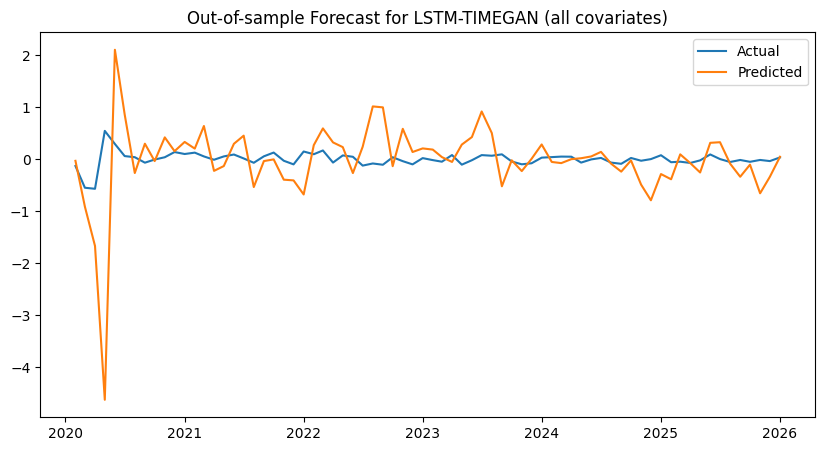

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_results['Date'], test_results["actual"], label="Actual")
plt.plot(test_results['Date'], test_results["predicted"], label="Predicted")
plt.legend()
plt.title("Out-of-sample Forecast for LSTM-TIMEGAN (all covariates)")
plt.show()

In [15]:
# save results to csv
test_results.to_csv('results/lstm-8-timegan_results.csv', index = False)